In [1]:
# Load Stage 0 foundation if this kernel has not run pipeline_foundation yet.
from pathlib import Path
import runpy


def _ensure_foundation():
    _required = ["DATA", "S1_FEATS", "scheme_splits", "process_split", "ndcg_at5"]
    _missing = [n for n in _required if n not in globals()]
    if not _missing:
        return
    root = Path.cwd()
    for candidate in [root, *list(root.parents)[:4]]:
        if (candidate / "pipeline_foundation.py").exists():
            root = candidate
            break
    py = root / "pipeline_foundation.py"
    if not py.exists():
        raise RuntimeError(
            "pipeline_foundation.py not found. Open this notebook from the "
            "SpeedDatingRecommender project folder, or run pipeline_foundation.ipynb first."
        )
    print(f"Loading foundation from {py} …")
    loaded = runpy.run_path(str(py), run_name="__foundation__")
    for name, value in loaded.items():
        if not name.startswith("_"):
            globals()[name] = value
    _still = [n for n in _required if n not in globals()]
    if _still:
        raise RuntimeError(f"Foundation load incomplete; still missing: {_still}")


_ensure_foundation()
print("Foundation globals OK — continue with Stage 1 cells below.")


Loading foundation from c:\SMU Subjects\Third Term\CS608-Recommender Systems\SpeedDatingRecommender\pipeline_foundation.py …
Wave reconstruction gate: PASSED
drop: rows=7,976  waves=20  dec=0.424  match=0.1678
keep: rows=8,368  waves=21  dec=0.4201  match=0.1649
S1 (keep): 21 splits OK
S2 (drop): 20 splits OK
S3 (keep): 3 splits OK
S4 (drop): 3 splits OK
S5 (keep): 4 splits OK
S6 (drop): 4 splits OK
S7 (keep): 4 splits OK
S8 (drop): 4 splits OK
S9 (keep): 21 splits OK
S10 (drop): 20 splits OK
smoke OK: train=3,822 eval=2,604 | align_attr range [-2.08, 1.83]
Foundation globals OK — continue with Stage 1 cells below.


In [2]:
# %pip install "interpret>=0.4"

In [3]:
# --- Stage 1 prerequisite check ---------------------------------------------
_required = ["DATA", "DATA_SHA", "S1_FEATS", "THEME_MAP", "THEMES",
             "scheme_splits", "process_split", "ndcg_at5", "ID_COLS",
             "RESULTS", "SEED", "CONFIG", "params_hash", "df_fingerprint"]
_missing = [n for n in _required if n not in globals()]
assert not _missing, (
    f"Run cell 0 first (loads foundation); missing: {_missing}"
)

import sys
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score

try:
    import interpret
    from interpret.glassbox import ExplainableBoostingClassifier
    assert hasattr(ExplainableBoostingClassifier, "eval_terms"), (
        "interpret too old — eval_terms() missing. Run: pip install -U 'interpret>=0.4'"
    )
    print(f"interpret {interpret.__version__} OK (kernel: {sys.executable})")
except ImportError as e:
    raise SystemExit(
        f"interpret not installed for this notebook kernel.\n"
        f"Kernel Python: {sys.executable}\n"
        f"Fix: {sys.executable} -m pip install \"interpret>=0.4\"\n"
        f"Or switch the notebook kernel to Python 3.14 where you already installed it."
    ) from e

print(f"S1_FEATS: {len(S1_FEATS)} features | themes: {len(THEMES)}")

interpret 0.7.8 OK (kernel: c:\Python314\python.exe)
S1_FEATS: 29 features | themes: 9


In [4]:
def _to_theme(contrib_df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-feature contributions into theme columns (shared helper)."""
    out = pd.DataFrame(0.0, index=contrib_df.index, columns=THEMES)
    for f in contrib_df.columns:
        out[THEME_MAP[f]] += contrib_df[f]
    return out


class Stage1LR:
    """Deck-named baseline: L2 logistic regression on dec over S1_FEATS."""

    name = "lr"

    def __init__(self, C=1.0, seed=SEED):
        self.C = C
        self.model = LogisticRegression(C=C, max_iter=2000, random_state=seed)

    def fit(self, train_df):
        self.model.fit(train_df[S1_FEATS].to_numpy(float), train_df["dec"])
        self.coef_ = pd.Series(self.model.coef_[0], index=S1_FEATS)
        self.intercept_ = float(self.model.intercept_[0])
        return self

    def predict_proba(self, df):
        return self.model.predict_proba(df[S1_FEATS].to_numpy(float))[:, 1]

    def contributions(self, df):
        X = df[S1_FEATS].to_numpy(float)
        C = X * self.model.coef_[0]
        logit = X @ self.model.coef_[0] + self.intercept_
        assert np.allclose(C.sum(1) + self.intercept_, logit, atol=1e-9), \
            "LR decomposition broke"
        return pd.DataFrame(C, columns=S1_FEATS, index=df.index)

    def theme_contributions(self, df):
        return _to_theme(self.contributions(df))

    def describe(self):
        return {"model": "LogisticRegression", "C": self.C, "penalty": "l2",
                "features": list(S1_FEATS)}


class Stage1EBM:
    """Contender: Explainable Boosting Machine, main effects only.
    logit = intercept + sum_j f_j(x_j); per-pair contribution of feature j
    is f_j(x_j) — same additive semantics as LR, learned shapes instead of
    straight lines."""

    name = "ebm"

    def __init__(self, seed=SEED, **overrides):
        self.params = dict(
            interactions=0,          # main effects ONLY (Stage 3 owns interactions)
            outer_bags=14,           # internal bagging stabilizes small-fold shapes
            learning_rate=0.01,
            max_bins=256,            # plenty for 8k rows; smoother than 1024
            random_state=seed,
            n_jobs=-1,
        )
        self.params.update(overrides)
        self.model = ExplainableBoostingClassifier(**self.params)

    def fit(self, train_df):
        self.model.fit(train_df[S1_FEATS], train_df["dec"])
        self.intercept_ = float(np.ravel(self.model.intercept_)[0])
        return self

    def predict_proba(self, df):
        return self.model.predict_proba(df[S1_FEATS])[:, 1]

    def contributions(self, df):
        terms = self.model.eval_terms(df[S1_FEATS])          # n x n_terms
        C = pd.DataFrame(terms, columns=self.model.term_names_, index=df.index)
        assert set(C.columns) == set(S1_FEATS), \
            f"EBM term mismatch: {set(S1_FEATS) ^ set(C.columns)}"
        C = C[list(S1_FEATS)]
        # exactness: sigma(intercept + sum terms) must equal predict_proba
        p_from_terms = 1.0 / (1.0 + np.exp(-(C.sum(1).to_numpy() + self.intercept_)))
        assert np.allclose(p_from_terms, self.predict_proba(df), atol=1e-6), \
            "EBM decomposition broke"
        return C

    def theme_contributions(self, df):
        return _to_theme(self.contributions(df))

    def describe(self):
        return {"model": "ExplainableBoostingClassifier", **self.params,
                "features": list(S1_FEATS)}


STAGE1_MODELS = {"lr": Stage1LR, "ebm": Stage1EBM}


def make_stage1():
    """Factory the pipeline runner should call (model choice lives in CONFIG)."""
    name = CONFIG.get("s1_model", "lr")
    if name == "lr":
        return Stage1LR(C=CONFIG.get("s1_C", 1.0))
    return Stage1EBM()

print("Stage 1 models ready:", list(STAGE1_MODELS))

Stage 1 models ready: ['lr', 'ebm']


In [5]:
_sp = scheme_splits("S8", DATA["drop"])[0]            # rr-fold 0
_tr, _ev, _ = process_split(DATA["drop"], _sp["train_waves"], _sp["eval_waves"])

for name, cls in STAGE1_MODELS.items():
    t0 = time.time()
    m = cls().fit(_tr)
    p = m.predict_proba(_ev)
    s = _ev[ID_COLS].copy()
    s["p"] = p
    ndcg, n_users = ndcg_at5(s, "p")
    print(f"{name:>4s}: AUC={roc_auc_score(_ev['dec'], p):.4f}  "
          f"logloss={log_loss(_ev['dec'], p, labels=[0,1]):.4f}  "
          f"NDCG5_uni={ndcg:.3f} ({n_users} users)  [{time.time()-t0:.0f}s]")

# explanation parity preview: same pair, both vocabularies
_pair = _ev.iloc[[0]]
print(f"\nDemo pair iid={int(_pair['iid'].iloc[0])} -> pid={int(_pair['pid'].iloc[0])}")
for name, cls in STAGE1_MODELS.items():
    th = cls().fit(_tr).theme_contributions(_pair).iloc[0]
    top = th.sort_values(ascending=False)
    print(f"  {name}: top {list(top.index[:2])} {top.values[:2].round(3)}"
          f" | bottom {list(top.index[-2:])} {top.values[-2:].round(3)}")

  lr: AUC=0.5913  logloss=0.6833  NDCG5_uni=0.407 (140 users)  [0s]
 ebm: AUC=0.5979  logloss=0.7228  NDCG5_uni=0.362 (140 users)  [9s]

Demo pair iid=1 -> pid=11
  lr: top ['Shared interests', 'Attractiveness'] [0.213 0.096] | bottom ['Ambition', 'Dating attitude'] [-0.219 -0.848]
  ebm: top ['Attractiveness', 'Sincerity'] [0.257 0.045] | bottom ['Shared interests', 'Dating attitude'] [-0.413 -0.656]


In [6]:
S8_CV = [sp for sp in scheme_splits("S8", DATA["drop"]) if sp["kind"] == "cv"]

CANDIDATES = {
    "lr_C0.1": lambda: Stage1LR(C=0.1),
    "lr_C1":   lambda: Stage1LR(C=1.0),
    "lr_C10":  lambda: Stage1LR(C=10.0),
    "ebm":     lambda: Stage1EBM(),
}

rows, theme_means = [], {}
for sp in S8_CV:
    tr, ev, _ = process_split(DATA["drop"], sp["train_waves"], sp["eval_waves"])
    for cand, ctor in CANDIDATES.items():
        t0 = time.time()
        m = ctor().fit(tr)
        p = m.predict_proba(ev)
        s = ev[ID_COLS].copy(); s["p"] = p
        ndcg, _n = ndcg_at5(s, "p")
        rows.append({"fold": sp["tag"], "cand": cand,
                     "auc": roc_auc_score(ev["dec"], p),
                     "logloss": log_loss(ev["dec"], p, labels=[0, 1]),
                     "ndcg5_uni": ndcg, "fit_s": round(time.time() - t0, 1)})
        theme_means[(cand, sp["tag"])] = m.theme_contributions(ev).mean()

h2h = pd.DataFrame(rows)
print(h2h.pivot(index="cand", columns="fold",
                values="auc").round(4).to_string())
summary = (h2h.groupby("cand")[["auc", "logloss", "ndcg5_uni"]]
              .agg(["mean", "std"]).round(4))
print("\n", summary.to_string())

# --- explanation stability: min pairwise cosine of fold-mean theme vectors ---
def _min_cosine(cand):
    V = np.stack([theme_means[(cand, sp["tag"])].to_numpy() for sp in S8_CV])
    Vn = V / np.linalg.norm(V, axis=1, keepdims=True)
    cos = Vn @ Vn.T
    return cos[np.triu_indices_from(cos, k=1)].min()

stab = {c: round(float(_min_cosine(c)), 4) for c in CANDIDATES}
print("\nExplanation stability (min fold-pair cosine):", stab)

# --- decision rule (plan section 4, recorded before running) ------------------
best_lr = (h2h[h2h["cand"].str.startswith("lr")]
           .groupby("cand")["auc"].mean().idxmax())
lr_auc  = h2h[h2h["cand"] == best_lr]["auc"].mean()
ebm_auc = h2h[h2h["cand"] == "ebm"]["auc"].mean()
ebm_wins = (ebm_auc - lr_auc >= 0.005) and (stab["ebm"] >= 0.90)
winner = "ebm" if ebm_wins else best_lr
print(f"\nbest LR: {best_lr} (AUC {lr_auc:.4f}) | EBM AUC {ebm_auc:.4f} | "
      f"delta {ebm_auc - lr_auc:+.4f}")
print(f"WINNER -> {winner}"
      f"{'' if ebm_wins else '  (EBM did not clear +0.005 AUC with stability >= 0.90)'}")

fold        cv0     cv1     cv2
cand                           
ebm      0.5979  0.6014  0.5955
lr_C0.1  0.5915  0.6219  0.6305
lr_C1    0.5913  0.6240  0.6287
lr_C10   0.5910  0.6245  0.6274

             auc         logloss         ndcg5_uni        
           mean     std    mean     std      mean     std
cand                                                     
ebm      0.5983  0.0030  0.7062  0.0149    0.3907  0.0446
lr_C0.1  0.6147  0.0205  0.6641  0.0155    0.4136  0.0682
lr_C1    0.6146  0.0204  0.6644  0.0164    0.4196  0.0668
lr_C10   0.6143  0.0203  0.6651  0.0169    0.4159  0.0667

Explanation stability (min fold-pair cosine): {'lr_C0.1': 0.3678, 'lr_C1': 0.5251, 'lr_C10': 0.5657, 'ebm': -0.7166}

best LR: lr_C0.1 (AUC 0.6147) | EBM AUC 0.5983 | delta -0.0164
WINNER -> lr_C0.1  (EBM did not clear +0.005 AUC with stability >= 0.90)


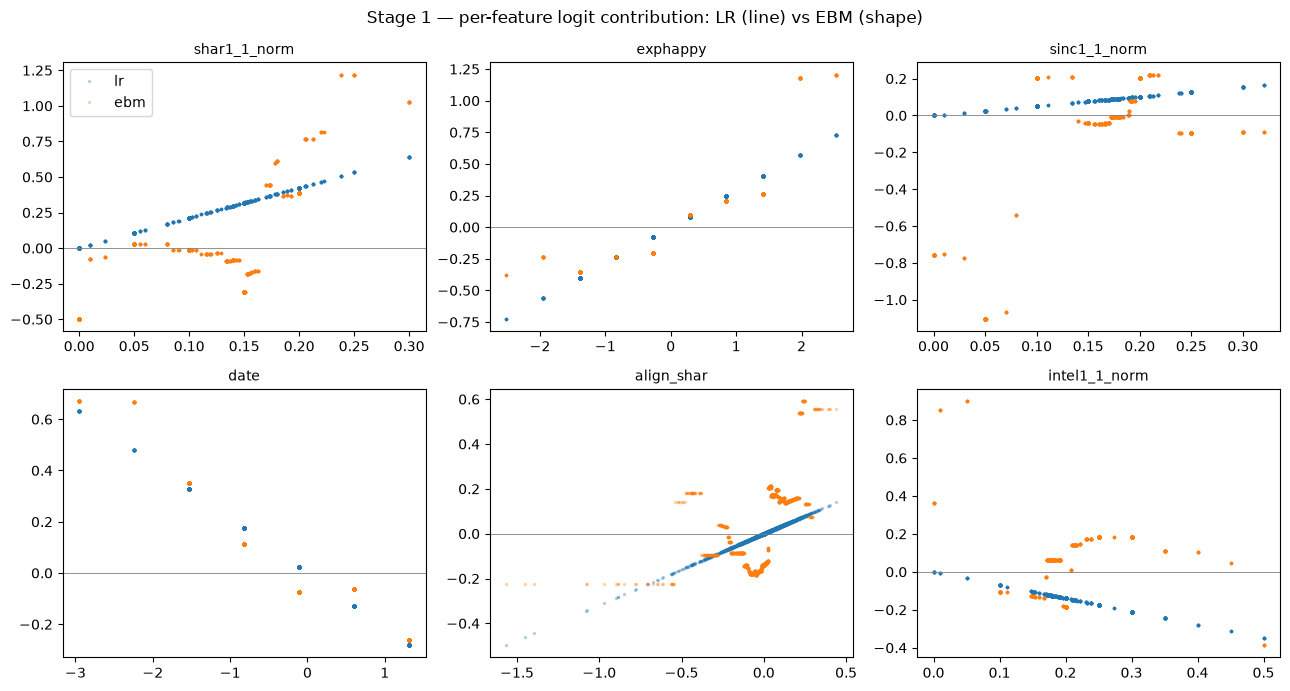

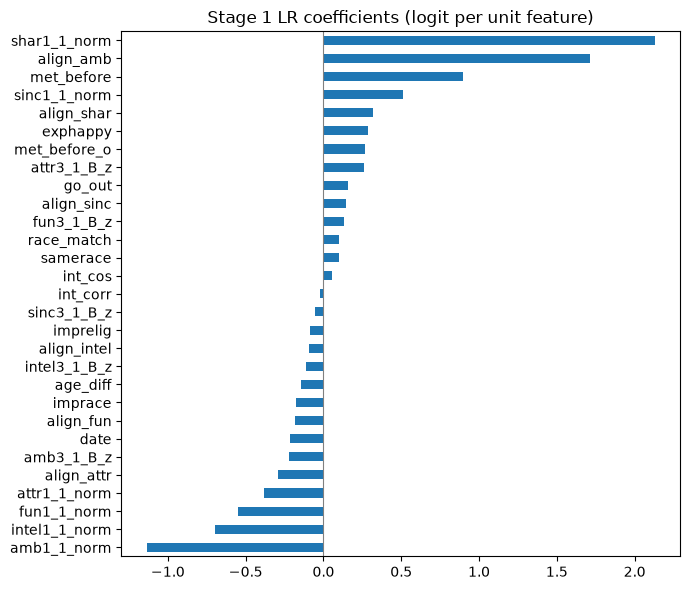

In [7]:
import matplotlib.pyplot as plt

_sp = S8_CV[0]
tr, ev, _ = process_split(DATA["drop"], _sp["train_waves"], _sp["eval_waves"])
fits = {name: cls().fit(tr) for name, cls in STAGE1_MODELS.items()}
contribs = {name: m.contributions(ev) for name, m in fits.items()}

top_feats = (contribs["ebm"].abs().mean().sort_values(ascending=False)
             .head(6).index.tolist())

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, f in zip(axes.ravel(), top_feats):
    for name, marker, alpha in [("lr", ".", 0.25), ("ebm", ".", 0.25)]:
        order = ev[f].argsort()
        ax.plot(ev[f].to_numpy()[order], contribs[name][f].to_numpy()[order],
                marker, ms=3, alpha=alpha, label=name)
    ax.axhline(0, color="gray", lw=0.6)
    ax.set_title(f, fontsize=10)
axes[0, 0].legend()
fig.suptitle("Stage 1 — per-feature logit contribution: LR (line) vs EBM (shape)")
fig.tight_layout()
(RESULTS / "figures" / "stage1").mkdir(exist_ok=True, parents=True)
fig.savefig(RESULTS / "figures" / "stage1" / "lr_vs_ebm_shapes.png", dpi=150)
plt.show()

coef_fig, ax = plt.subplots(figsize=(7, 6))
fits["lr"].coef_.sort_values().plot.barh(ax=ax)
ax.set_title("Stage 1 LR coefficients (logit per unit feature)")
ax.axvline(0, color="gray", lw=0.8)
coef_fig.tight_layout()
coef_fig.savefig(RESULTS / "figures" / "stage1" / "lr_coefficients.png", dpi=150)
plt.show()

In [8]:
stage1_decision = {
    "ts": time.strftime("%Y-%m-%d %H:%M:%S"),
    "decision_rule": "EBM needs >= +0.005 mean AUC over best LR on S8 CV "
                     "and min fold-pair theme-cosine >= 0.90; ties -> LR",
    "winner": winner,
    "candidates": {c: {"auc_mean": float(h2h[h2h['cand'] == c]['auc'].mean()),
                       "auc_std": float(h2h[h2h['cand'] == c]['auc'].std()),
                       "ndcg5_uni_mean": float(h2h[h2h['cand'] == c]['ndcg5_uni'].mean()),
                       "stability_min_cos": stab[c]}
                   for c in CANDIDATES},
    "winner_params": (Stage1EBM() if winner == "ebm"
                      else Stage1LR(C=float(winner.split("C")[1]))).describe(),
    "tuning_scheme": "S8 (drop-w12, holdout [8,13,14,19]) CV folds only",
    "data_sha": DATA_SHA, "data_fingerprint": df_fingerprint(DATA["drop"]),
    "config_hash": params_hash(CONFIG),
    "per_fold": h2h.to_dict("records"),
}
out = RESULTS / "runs" / f"stage1_decision_{time.strftime('%Y%m%d_%H%M%S')}.json"
out.write_text(json.dumps(stage1_decision, indent=2), encoding="utf-8")
print(f"Saved {out.name}")
_expected = "ebm" if winner == "ebm" else "lr"
_ok = CONFIG.get("s1_model") == _expected and CONFIG.get("FROZEN")
print(f"\nFrozen CONFIG: s1_model={CONFIG.get('s1_model')} s1_C={CONFIG.get('s1_C')} FROZEN={CONFIG.get('FROZEN')} deploy_scheme={CONFIG.get('deploy_scheme')}")
print("  -> matches decision winner (frozen in pipeline_foundation.py)" if _ok
      else "  -> MISMATCH: update CONFIG in pipeline_foundation.py")

Saved stage1_decision_20260616_162142.json

Frozen CONFIG: s1_model=lr s1_C=0.1 FROZEN=True deploy_scheme=S9
  -> matches decision winner (frozen in pipeline_foundation.py)


## All 10 splitting schemes × {LR, EBM}

Gate for Stage 2: compare **both Stage-1 models under every protocol** before
progressing. LR runs at C=0.1 (cell-5 tuning); EBM with the fixed main-effects
params. Each split is preprocessed **once** and both models fit on the same
matrices, so model differences are never preprocessing differences.

| Scheme | Protocol | Wave 12 | Splits |
|---|---|---|---|
| S1 / S2 | Leave-one-wave-out | kept / dropped | 21 / 20 |
| S3 / S4 | Deck tri-fold CV | kept (w12→Fold 3) / dropped | 3 / 3 |
| S5 / S6 | 3-fold CV + holdout [1,9,15,18] | kept (w12→cv2) / dropped | 3+1 |
| S7 / S8 | 3-fold CV + holdout [8,13,14,19] | kept (round-robin) / dropped | 3+1 |
| S9 / S10 | LOWO + wave-19 holdout | kept / dropped | 20+1 / 19+1 |

⏱ full run ≈ 25–30 min (104 splits × EBM ~10 s dominates; LR is negligible).
Run scheme cells individually if you only need a subset refreshed.

In [9]:
# Shared runner: both Stage-1 models on every split of a scheme ------------------
MODELS = {
    "lr":  lambda: Stage1LR(C=0.1),   # cell-5 tuned C
    "ebm": lambda: Stage1EBM(),
}
SCHEME_RESULTS = {}   # scheme_id -> per-(split x model) DataFrame


def run_scheme_stage1(scheme_id, models=MODELS):
    """Preprocess each split once; fit every model on the same matrices."""
    df = DATA[SCHEME_VARIANT[scheme_id]]
    rows = []
    for sp in scheme_splits(scheme_id, df):
        tr, ev, _ = process_split(df, sp["train_waves"], sp["eval_waves"])
        for mname, ctor in models.items():
            t0 = time.time()
            m = ctor().fit(tr)
            p = m.predict_proba(ev)
            s = ev[ID_COLS].copy()
            s["p"] = p
            nd, n_users = ndcg_at5(s, "p")
            rows.append({"scheme": scheme_id, "variant": SCHEME_VARIANT[scheme_id],
                         "model": mname, "tag": sp["tag"], "kind": sp["kind"],
                         "auc": roc_auc_score(ev["dec"], p),
                         "logloss": log_loss(ev["dec"], p, labels=[0, 1]),
                         "ndcg5_uni": nd, "n_users": n_users,
                         "fit_s": round(time.time() - t0, 1)})
    out = pd.DataFrame(rows)
    print(f"[{scheme_id} | {SCHEME_VARIANT[scheme_id]}-w12] "
          f"{out['tag'].nunique()} splits x {len(models)} models")
    for mname in models:
        r = out[out["model"] == mname]
        cv = r[r["kind"] != "holdout"]
        line = (f"  {mname:>4s}: AUC {cv['auc'].mean():.4f} +/- {cv['auc'].std():.4f}"
                f" | log-loss {cv['logloss'].mean():.4f} +/- {cv['logloss'].std():.4f}"
                f" | NDCG@5 {cv['ndcg5_uni'].mean():.4f} +/- {cv['ndcg5_uni'].std():.4f}")
        for _, h in r[r["kind"] == "holdout"].iterrows():
            line += f" | HOLD({h['tag']}) AUC {h['auc']:.4f} NDCG {h['ndcg5_uni']:.4f}"
        print(line)
    SCHEME_RESULTS[scheme_id] = out
    return out


print("Runner ready. Models:", list(MODELS))

Runner ready. Models: ['lr', 'ebm']


In [10]:
# --- S1: LOWO, wave 12 KEPT (21 rounds). Wave 12 also rotates in as a test wave:
# its censored labels should make it one of the worst test waves.
res_s1 = run_scheme_stage1("S1")
per_wave = (res_s1[res_s1['kind'] == 'lowo']
            .pivot(index='tag', columns='model', values='auc')
            .assign(wave=lambda d: d.index.str.replace('wave', '').astype(int))
            .sort_values('wave').set_index('wave'))
print()
print(per_wave.round(4).to_string())


[S1 | keep-w12] 21 splits x 2 models
    lr: AUC 0.5934 +/- 0.0598 | log-loss 0.6731 +/- 0.0270 | NDCG@5 0.4406 +/- 0.1458
   ebm: AUC 0.5671 +/- 0.0798 | log-loss 0.7243 +/- 0.0781 | NDCG@5 0.4111 +/- 0.1445

model     ebm      lr
wave                 
1      0.4163  0.5589
2      0.6307  0.6514
3      0.5072  0.5776
4      0.5841  0.6000
5      0.6567  0.6411
6      0.6816  0.5712
7      0.6271  0.6786
8      0.5094  0.5608
9      0.6521  0.6303
10     0.5158  0.6181
11     0.5798  0.6210
12     0.5120  0.4796
13     0.4839  0.5250
14     0.5180  0.5956
15     0.5209  0.5241
16     0.5363  0.4891
17     0.7494  0.7241
18     0.5031  0.5828
19     0.5144  0.5802
20     0.5936  0.6297
21     0.6167  0.6227


In [11]:
# --- S2: LOWO, wave 12 DROPPED (20 rounds). Paired with S1 -> wave-12 effect under LOWO.
res_s2 = run_scheme_stage1("S2")
per_wave = (res_s2[res_s2['kind'] == 'lowo']
            .pivot(index='tag', columns='model', values='auc')
            .assign(wave=lambda d: d.index.str.replace('wave', '').astype(int))
            .sort_values('wave').set_index('wave'))
print()
print(per_wave.round(4).to_string())


[S2 | drop-w12] 20 splits x 2 models
    lr: AUC 0.5996 +/- 0.0554 | log-loss 0.6731 +/- 0.0280 | NDCG@5 0.4453 +/- 0.1367
   ebm: AUC 0.5745 +/- 0.0821 | log-loss 0.7257 +/- 0.0848 | NDCG@5 0.4274 +/- 0.1493

model     ebm      lr
wave                 
1      0.4138  0.5586
2      0.6393  0.6506
3      0.5251  0.5770
4      0.5981  0.6021
5      0.6571  0.6375
6      0.6992  0.5808
7      0.6462  0.6810
8      0.5101  0.5667
9      0.6459  0.6323
10     0.5187  0.6113
11     0.5874  0.6174
13     0.4887  0.5180
14     0.5155  0.5986
15     0.5390  0.5254
16     0.5420  0.4851
17     0.7416  0.7188
18     0.4867  0.5898
19     0.5147  0.5768
20     0.6117  0.6426
21     0.6087  0.6222


In [12]:
# --- S3: Deck tri-fold CV (p.10 folds), wave 12 KEPT (appended to Fold 3).
res_s3 = run_scheme_stage1("S3")


[S3 | keep-w12] 3 splits x 2 models
    lr: AUC 0.6036 +/- 0.0135 | log-loss 0.6650 +/- 0.0068 | NDCG@5 0.3975 +/- 0.0521
   ebm: AUC 0.5712 +/- 0.0154 | log-loss 0.7173 +/- 0.0131 | NDCG@5 0.3490 +/- 0.0142


In [13]:
# --- S4: Deck tri-fold CV exactly as presented, wave 12 DROPPED. Comparable to team results.
res_s4 = run_scheme_stage1("S4")


[S4 | drop-w12] 3 splits x 2 models
    lr: AUC 0.6067 +/- 0.0113 | log-loss 0.6654 +/- 0.0070 | NDCG@5 0.3957 +/- 0.0490
   ebm: AUC 0.5793 +/- 0.0074 | log-loss 0.7110 +/- 0.0075 | NDCG@5 0.3500 +/- 0.0132


In [14]:
# --- S5: 3-fold CV + holdout [1,9,15,18] (the original adversarial holdout), wave 12 KEPT (in cv2).
res_s5 = run_scheme_stage1("S5")


[S5 | keep-w12] 4 splits x 2 models
    lr: AUC 0.6089 +/- 0.0317 | log-loss 0.6613 +/- 0.0112 | NDCG@5 0.3940 +/- 0.0168 | HOLD(holdout) AUC 0.5883 NDCG 0.3960
   ebm: AUC 0.5703 +/- 0.0204 | log-loss 0.7119 +/- 0.0349 | NDCG@5 0.3856 +/- 0.0214 | HOLD(holdout) AUC 0.5764 NDCG 0.3357


In [15]:
# --- S6: 3-fold CV + holdout [1,9,15,18], wave 12 DROPPED (= run_preprocessing scheme_2 verbatim).
# Expect the holdout to read LOW vs its CV band - that is the known composition bias.
res_s6 = run_scheme_stage1("S6")


[S6 | drop-w12] 4 splits x 2 models
    lr: AUC 0.6142 +/- 0.0215 | log-loss 0.6618 +/- 0.0113 | NDCG@5 0.4007 +/- 0.0310 | HOLD(holdout) AUC 0.5911 NDCG 0.3964
   ebm: AUC 0.5723 +/- 0.0187 | log-loss 0.7145 +/- 0.0309 | NDCG@5 0.3933 +/- 0.0171 | HOLD(holdout) AUC 0.5841 NDCG 0.3285


In [16]:
# --- S7: 3-fold CV + holdout [8,13,14,19] (representative), wave 12 KEPT in the pool.
res_s7 = run_scheme_stage1("S7")


[S7 | keep-w12] 4 splits x 2 models
    lr: AUC 0.6072 +/- 0.0173 | log-loss 0.6631 +/- 0.0081 | NDCG@5 0.4178 +/- 0.0734 | HOLD(holdout) AUC 0.5778 NDCG 0.3312
   ebm: AUC 0.5920 +/- 0.0149 | log-loss 0.7024 +/- 0.0228 | NDCG@5 0.3824 +/- 0.0568 | HOLD(holdout) AUC 0.5167 NDCG 0.3383


In [17]:
# --- S8: 3-fold CV + holdout [8,13,14,19], wave 12 DROPPED - the designated tuning scheme.
# Expect holdout to sit INSIDE the CV band (representative-holdout result).
res_s8 = run_scheme_stage1("S8")


[S8 | drop-w12] 4 splits x 2 models
    lr: AUC 0.6147 +/- 0.0205 | log-loss 0.6641 +/- 0.0155 | NDCG@5 0.4136 +/- 0.0682 | HOLD(holdout) AUC 0.5780 NDCG 0.3406
   ebm: AUC 0.5983 +/- 0.0030 | log-loss 0.7062 +/- 0.0149 | NDCG@5 0.3907 +/- 0.0446 | HOLD(holdout) AUC 0.5152 NDCG 0.3303


In [18]:
# --- S9: LOWO + wave-19 holdout, wave 12 KEPT (w12 rotates; 19 never does).
res_s9 = run_scheme_stage1("S9")

# Consistency: S9 holdout and S1's wave-19 round share train waves + eval wave.
for mn in MODELS:
    a = res_s1[(res_s1['tag'] == 'wave19') & (res_s1['model'] == mn)]['auc'].iloc[0]
    b = res_s9[(res_s9['kind'] == 'holdout') & (res_s9['model'] == mn)]['auc'].iloc[0]
    flag = 'OK' if abs(a - b) < 1e-9 else 'WARNING - investigate'
    print(f'consistency {mn}: S1/wave19 {a:.6f} vs S9/holdout {b:.6f} -> {flag}')


[S9 | keep-w12] 21 splits x 2 models
    lr: AUC 0.5938 +/- 0.0626 | log-loss 0.6729 +/- 0.0284 | NDCG@5 0.4438 +/- 0.1466 | HOLD(holdout_w19) AUC 0.5802 NDCG 0.4136
   ebm: AUC 0.5699 +/- 0.0834 | log-loss 0.7269 +/- 0.0850 | NDCG@5 0.4217 +/- 0.1419 | HOLD(holdout_w19) AUC 0.5144 NDCG 0.2843
consistency lr: S1/wave19 0.580181 vs S9/holdout 0.580181 -> OK
consistency ebm: S1/wave19 0.514423 vs S9/holdout 0.514423 -> OK


In [19]:
# --- S10: LOWO + wave-19 holdout, wave 12 DROPPED.
res_s10 = run_scheme_stage1("S10")

for mn in MODELS:
    a = res_s2[(res_s2['tag'] == 'wave19') & (res_s2['model'] == mn)]['auc'].iloc[0]
    b = res_s10[(res_s10['kind'] == 'holdout') & (res_s10['model'] == mn)]['auc'].iloc[0]
    flag = 'OK' if abs(a - b) < 1e-9 else 'WARNING - investigate'
    print(f'consistency {mn}: S2/wave19 {a:.6f} vs S10/holdout {b:.6f} -> {flag}')


[S10 | drop-w12] 20 splits x 2 models
    lr: AUC 0.6012 +/- 0.0574 | log-loss 0.6729 +/- 0.0295 | NDCG@5 0.4431 +/- 0.1397 | HOLD(holdout_w19) AUC 0.5768 NDCG 0.4191
   ebm: AUC 0.5747 +/- 0.0922 | log-loss 0.7249 +/- 0.0850 | NDCG@5 0.4272 +/- 0.1546 | HOLD(holdout_w19) AUC 0.5147 NDCG 0.2957
consistency lr: S2/wave19 0.576764 vs S10/holdout 0.576764 -> OK
consistency ebm: S2/wave19 0.514681 vs S10/holdout 0.514681 -> OK


In [20]:
# === Final comparison: 10 schemes x 2 models ====================================
assert len(SCHEME_RESULTS) == 10, f"run all scheme cells first (have {sorted(SCHEME_RESULTS)})"
allr = pd.concat(SCHEME_RESULTS.values(), ignore_index=True)

ORDER = ["S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10"]
LABEL = {"S1": "LOWO keep", "S2": "LOWO drop", "S3": "trifold keep", "S4": "trifold drop",
         "S5": "cv+hold[1,9,15,18] keep", "S6": "cv+hold[1,9,15,18] drop",
         "S7": "cv+hold[8,13,14,19] keep", "S8": "cv+hold[8,13,14,19] drop",
         "S9": "LOWO+hold19 keep", "S10": "LOWO+hold19 drop"}

for mn in MODELS:
    print("=" * 84)
    print(f"MODEL: {mn}")
    print("=" * 84)
    rows = []
    for sid in ORDER:
        r = allr[(allr["scheme"] == sid) & (allr["model"] == mn)]
        cv = r[r["kind"] != "holdout"]
        h = r[r["kind"] == "holdout"]
        rows.append({"scheme": sid, "protocol": LABEL[sid],
                     "cv_auc": f"{cv['auc'].mean():.4f} +/- {cv['auc'].std():.4f}",
                     "hold_auc": f"{h['auc'].iloc[0]:.4f}" if len(h) else "-",
                     "cv_ndcg5": f"{cv['ndcg5_uni'].mean():.4f} +/- {cv['ndcg5_uni'].std():.4f}",
                     "hold_ndcg5": f"{h['ndcg5_uni'].iloc[0]:.4f}" if len(h) else "-"})
    print(pd.DataFrame(rows).to_string(index=False))
    print()

# --- wave-12 paired deltas (kept - dropped), like-for-like ----------------------
PAIRS = [("S1", "S2"), ("S3", "S4"), ("S5", "S6"), ("S7", "S8"), ("S9", "S10")]


def paired_delta(keep_id, drop_id, mn, metric):
    k = allr[(allr["scheme"] == keep_id) & (allr["model"] == mn) & (allr["kind"] != "holdout")]
    d = allr[(allr["scheme"] == drop_id) & (allr["model"] == mn) & (allr["kind"] != "holdout")]
    if keep_id in ("S1", "S9"):                       # LOWO: common waves only
        common = set(k["tag"]) & set(d["tag"])
        k, d = k[k["tag"].isin(common)], d[d["tag"].isin(common)]
    return k[metric].mean() - d[metric].mean()


print("Wave-12 effect (kept - dropped) on CV/LOWO means; negative = w12 hurts:")
drows = []
for kid, did in PAIRS:
    drows.append({"pair": f"{kid}-{did}",
                  **{f"{mn}_d_auc": round(paired_delta(kid, did, mn, "auc"), 4)
                     for mn in MODELS},
                  **{f"{mn}_d_ndcg": round(paired_delta(kid, did, mn, "ndcg5_uni"), 4)
                     for mn in MODELS}})
print(pd.DataFrame(drows).to_string(index=False))

# --- LR vs EBM verdict across schemes -------------------------------------------
print()
wins = 0
for sid in ORDER:
    r = allr[(allr["scheme"] == sid) & (allr["kind"] != "holdout")]
    lr_auc = r[r["model"] == "lr"]["auc"].mean()
    ebm_auc = r[r["model"] == "ebm"]["auc"].mean()
    wins += lr_auc > ebm_auc
g = allr[allr["kind"] != "holdout"].groupby("model")["auc"].mean()
print(f"VERDICT: LR beats EBM on CV/LOWO mean AUC in {wins}/10 schemes "
      f"(grand mean: lr {g['lr']:.4f} vs ebm {g['ebm']:.4f})")

# --- provenance ------------------------------------------------------------------
rec = {"ts": time.strftime("%Y-%m-%d %H:%M:%S"),
       "models": {"lr": "LogisticRegression C=0.1", "ebm": "EBM main-effects (cell-3 params)"},
       "results": allr.to_dict("records"),
       "data_sha": DATA_SHA,
       "fingerprints": {k: df_fingerprint(DATA[k]) for k in DATA},
       "config_hash": params_hash(CONFIG),
       "metrics_version": CONFIG["metrics_version"]}
out_path = RESULTS / "runs" / f"stage1_all_schemes_{time.strftime('%Y%m%d_%H%M%S')}.json"
out_path.write_text(json.dumps(rec, indent=2, default=str), encoding="utf-8")
allr.to_parquet(RESULTS / "stage1_scheme_metrics.parquet", index=False)
print(f"\nSaved {out_path.name} and results/stage1_scheme_metrics.parquet")

MODEL: lr
scheme                 protocol            cv_auc hold_auc          cv_ndcg5 hold_ndcg5
    S1                LOWO keep 0.5934 +/- 0.0598        - 0.4406 +/- 0.1458          -
    S2                LOWO drop 0.5996 +/- 0.0554        - 0.4453 +/- 0.1367          -
    S3             trifold keep 0.6036 +/- 0.0135        - 0.3975 +/- 0.0521          -
    S4             trifold drop 0.6067 +/- 0.0113        - 0.3957 +/- 0.0490          -
    S5  cv+hold[1,9,15,18] keep 0.6089 +/- 0.0317   0.5883 0.3940 +/- 0.0168     0.3960
    S6  cv+hold[1,9,15,18] drop 0.6142 +/- 0.0215   0.5911 0.4007 +/- 0.0310     0.3964
    S7 cv+hold[8,13,14,19] keep 0.6072 +/- 0.0173   0.5778 0.4178 +/- 0.0734     0.3312
    S8 cv+hold[8,13,14,19] drop 0.6147 +/- 0.0205   0.5780 0.4136 +/- 0.0682     0.3406
    S9         LOWO+hold19 keep 0.5938 +/- 0.0626   0.5802 0.4438 +/- 0.1466     0.4136
   S10         LOWO+hold19 drop 0.6012 +/- 0.0574   0.5768 0.4431 +/- 0.1397     0.4191

MODEL: ebm
scheme    

## Stage 1 final — S9 deployment: scores + explainability

**Methodology bridge.** The LR-vs-EBM choice and `C=0.1` were tuned **once on S8**
(the pre-registered tuning scheme) and held 10/10 across all schemes, so they
carry over unchanged. From here, training/scoring follows **S9** (LOWO over the
20 non-19 waves + wave-19 holdout, wave 12 kept). The frozen choice lives in
`CONFIG` (`s1_model='lr'`, `s1_C=0.1`, `deploy_scheme='S9'`, `FROZEN=True`) and
`make_stage1()` reads it — so these cells need only the foundation (cell 0) and
the model classes (cell 3), not the 10-scheme sweep above.

Outputs the canonical Stage-1 artifacts for Stages 2–4 and the deck:
out-of-fold `score_cb(A→B)` for all 8,368 rows + the `score_cb_rev(B→A)` mirror,
per-pair match cards, and the factor-contribution distributions.

In [21]:
# P1 -- canonical S9 score_cb(A->B) + mirror(B->A) + per-row theme contributions
import time
assert CONFIG.get("FROZEN") and CONFIG.get("s1_model") == "lr", \
    "Freeze CONFIG (s1_model='lr', s1_C=0.1, FROZEN=True) in pipeline_foundation.py first."

df_s9 = DATA["keep"]                       # S9 keeps wave 12
contrib_cols = [f"contrib_{t}" for t in THEMES]
parts = []
for sp in scheme_splits("S9", df_s9):
    tr, ev, _ = process_split(df_s9, sp["train_waves"], sp["eval_waves"])
    m = make_stage1().fit(tr)              # frozen LR(C=0.1)
    block = ev[["iid", "pid", "gender", "wave", "dec", "dec_o", "match"]].copy()
    block["score_cb"] = m.predict_proba(ev)
    block[contrib_cols] = m.theme_contributions(ev).values     # logit-space, sums to logit-intercept
    block["split_tag"], block["split_kind"] = sp["tag"], sp["kind"]
    parts.append(block)

s9 = (pd.concat(parts, ignore_index=True)
      .sort_values(["wave", "iid", "pid"]).reset_index(drop=True))
s9["score_cb_rev"] = mirror_col(s9, "score_cb")    # B->A; Stage-4 reciprocal needs this

# verify reproduction of the reported S9 LR numbers
lowo, hold = s9[s9["split_kind"] == "lowo"], s9[s9["split_kind"] == "holdout"]
lowo_auc = [roc_auc_score(d["dec"], d["score_cb"])
            for _, d in lowo.groupby("split_tag") if d["dec"].nunique() == 2]
print(f"rows {len(s9)} (expect 8368) | "
      f"LOWO AUC {np.mean(lowo_auc):.4f} +/- {np.std(lowo_auc):.4f} (rep 0.5938 +/- 0.0626) | "
      f"HOLD AUC {roc_auc_score(hold['dec'], hold['score_cb']):.4f} (rep 0.5802)")

s9.to_parquet(RESULTS / "stage1_s9_scores.parquet", index=False)
s9.to_csv(RESULTS / "stage1_s9_scores.csv", index=False)
prov = {"ts": time.strftime("%Y-%m-%d %H:%M:%S"), "scheme": "S9",
        "model": make_stage1().describe(), "n_rows": len(s9),
        "lowo_auc_mean": float(np.mean(lowo_auc)),
        "holdout_auc": float(roc_auc_score(hold["dec"], hold["score_cb"])),
        "columns": list(s9.columns), "data_sha": DATA_SHA,
        "fingerprint": df_fingerprint(df_s9), "config_hash": params_hash(CONFIG)}
(RESULTS / "runs" / f"stage1_s9_scores_{time.strftime('%Y%m%d_%H%M%S')}.json").write_text(
    json.dumps(prov, indent=2, default=str), encoding="utf-8")
print("saved results/stage1_s9_scores.parquet (+ .csv, + provenance json)")
s9.head(3)

rows 8368 (expect 8368) | LOWO AUC 0.5938 +/- 0.0610 (rep 0.5938 +/- 0.0626) | HOLD AUC 0.5802 (rep 0.5802)
saved results/stage1_s9_scores.parquet (+ .csv, + provenance json)


,iid,pid,gender,wave,dec,dec_o,match,score_cb,contrib_Ambition,contrib_Attractiveness,contrib_Dating attitude,contrib_Demographics fit,contrib_Familiarity,contrib_Fun,contrib_Intelligence,contrib_Shared interests,contrib_Sincerity,split_tag,split_kind,score_cb_rev
0,1,11.0,0,1,1,0,0,0.294309,-0.044202,0.098308,-0.588486,0.042811,0.000000,-0.074119,0.020474,0.065017,0.051861,wave1,lowo,0.412694
1,1,12.0,0,1,1,0,0,0.492243,-0.043554,0.230630,-0.588486,0.179271,0.599440,0.080811,-0.225224,0.130431,0.051861,wave1,lowo,0.580331
2,1,13.0,0,1,1,1,1,0.491996,-0.044527,-0.430977,-0.588486,0.392810,0.903143,0.003346,0.020474,0.071046,0.087362,wave1,lowo,0.511083


In [22]:
# P1 -- per-pair match card (Stage-1 unilateral: why A is likely to say yes to B)
CARD_PHRASE = {"Attractiveness": "physical attractiveness", "Sincerity": "sincerity",
               "Intelligence": "intelligence", "Fun": "being fun", "Ambition": "ambition",
               "Shared interests": "shared interests", "Demographics fit": "background fit",
               "Dating attitude": "dating attitude", "Familiarity": "prior familiarity"}


def render_card(scores_df, iid, pid, top_pos=3, top_neg=2):
    """Theme-level explanation for one directed pair, read off the saved
    logit-space contributions (exact: they sum to the logit minus intercept)."""
    row = scores_df[(scores_df["iid"] == iid) & (scores_df["pid"] == pid)]
    if row.empty:
        return f"(no scored pair {iid}->{pid})"
    row = row.iloc[0]
    th = pd.Series({t: row[f"contrib_{t}"] for t in THEMES}).sort_values(ascending=False)
    L = [f"We recommend participant #{pid} to participant #{iid}",
         f"  P(#{iid} -> yes to #{pid}) = {row['score_cb']:.0%}"
         f"   |  reciprocal P(#{pid} -> yes) = {row['score_cb_rev']:.0%}",
         "", "Why this could work (top factors toward yes):"]
    for t, v in th[th > 0].head(top_pos).items():
        L.append(f"   + {CARD_PHRASE[t]:<24s} (+{v:.3f})")
    neg = th[th < 0]
    if len(neg):
        L += ["", "What may work against it:"]
        for t, v in neg.tail(top_neg).items():
            L.append(f"   - {CARD_PHRASE[t]:<24s} ({v:.3f})")
    gt = "MATCHED" if row["match"] == 1 else ("A said yes" if row["dec"] == 1 else "A said no")
    L += ["", f"  (ground truth: {gt})"]
    return "\n".join(L)


# demo: the held-out wave-19 pair the model rated most likely
demo = s9[s9["wave"] == 19].sort_values("score_cb", ascending=False).iloc[0]
print(render_card(s9, int(demo["iid"]), int(demo["pid"])))

We recommend participant #469 to participant #493
  P(#493 -> yes to #469) = 75%   |  reciprocal P(#469 -> yes) = 51%

Why this could work (top factors toward yes):
   + dating attitude          (+0.743)
   + background fit           (+0.386)
   + intelligence             (+0.289)

What may work against it:
   - physical attractiveness  (-0.018)
   - being fun                (-0.055)

  (ground truth: MATCHED)


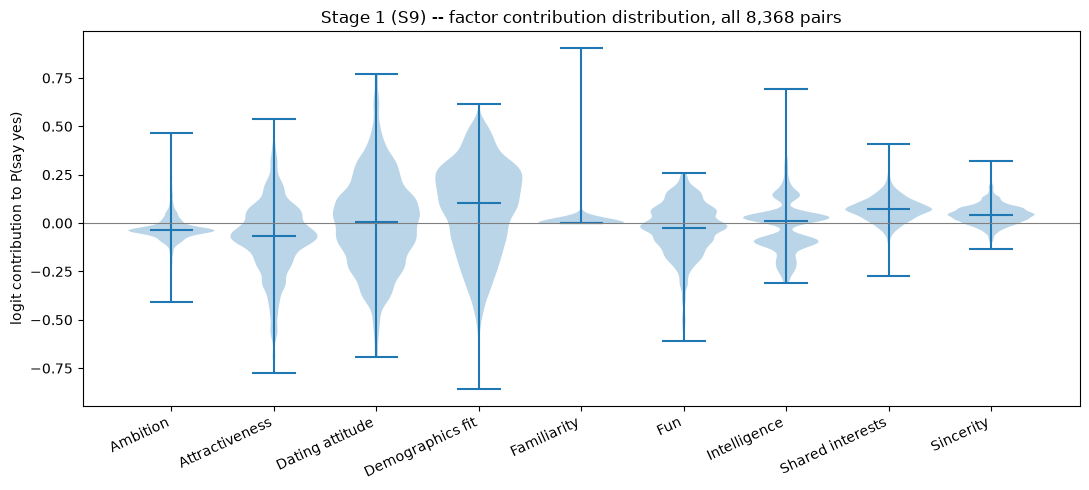

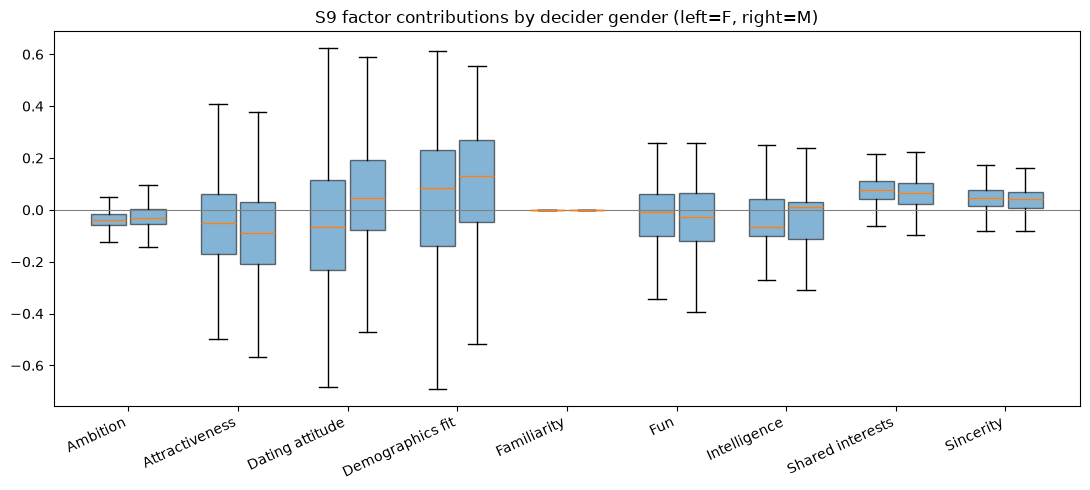

Mean |theme contribution| (drives decisions most -> least):
Demographics fit    0.2070
Dating attitude     0.1926
Attractiveness      0.1547
Intelligence        0.1088
Fun                 0.1069
Shared interests    0.0794
Ambition            0.0569
Sincerity           0.0545
Familiarity         0.0346


In [23]:
# P2 -- distribution of factor contributions across all S9 eval pairs
import matplotlib.pyplot as plt
fig_dir = RESULTS / "figures" / "stage1"; fig_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 5))
ax.violinplot([s9[c] for c in contrib_cols], showmedians=True, widths=0.85)
ax.set_xticks(range(1, len(THEMES) + 1)); ax.set_xticklabels(THEMES, rotation=25, ha="right")
ax.axhline(0, color="gray", lw=0.8); ax.set_ylabel("logit contribution to P(say yes)")
ax.set_title("Stage 1 (S9) -- factor contribution distribution, all 8,368 pairs")
fig.tight_layout(); fig.savefig(fig_dir / "s9_factor_distributions.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
for gv, off in [(0, -0.18), (1, 0.18)]:
    gd = s9[s9["gender"] == gv]
    bp = ax.boxplot([gd[c] for c in contrib_cols], positions=np.arange(len(THEMES)) + off,
                    widths=0.32, patch_artist=True, showfliers=False)
    for b in bp["boxes"]:
        b.set_alpha(0.55)
ax.set_xticks(range(len(THEMES))); ax.set_xticklabels(THEMES, rotation=25, ha="right")
ax.axhline(0, color="gray", lw=0.8)
ax.set_title("S9 factor contributions by decider gender (left=F, right=M)")
fig.tight_layout(); fig.savefig(fig_dir / "s9_factor_by_gender.png", dpi=150); plt.show()

imp = s9[contrib_cols].abs().mean().sort_values(ascending=False)
imp.index = [c.replace("contrib_", "") for c in imp.index]
print("Mean |theme contribution| (drives decisions most -> least):")
print(imp.round(4).to_string())